In [3]:
import warnings
warnings.filterwarnings('ignore')

### Importing Libraries


In [46]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [47]:
from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

### LOAD DATASET

In [48]:
df=pd.read_csv("C:\\Users\\Karthik\\Downloads\\IBM_teleco_Customer_Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,2967-MXRAV,Male,0,Yes,Yes,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,18.80,18.80,No
1,8992-CEUEN,Female,0,No,No,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Electronic check,18.85,18.85,No
2,9318-NKNFC,Male,0,No,No,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,18.85,18.85,Yes
3,9975-SKRNR,Male,0,No,No,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,18.90,18.90,No
4,1423-BMPBQ,Female,0,Yes,Yes,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,19.00,19.00,No


### Understanding the dataset

In [49]:
df.shape

(7043, 21)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [51]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [52]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# EXPLORATORY DATA ANALYSIS(EDA)

### 1.Checking target varaiable distribution

In [53]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [55]:
df['Churn'].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

### Customer churn count (Bar Chart)

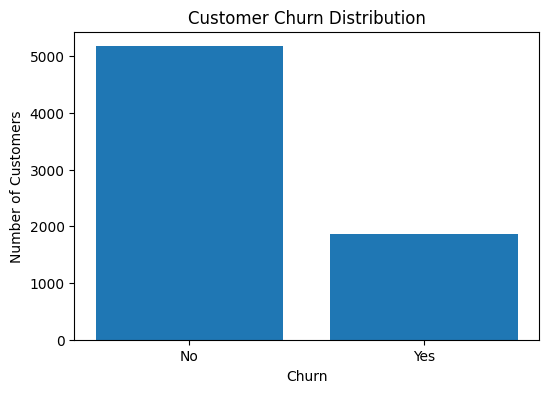

In [21]:
churn_counts=df['Churn'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(churn_counts.index,churn_counts.values)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

### Contract Type Distribution

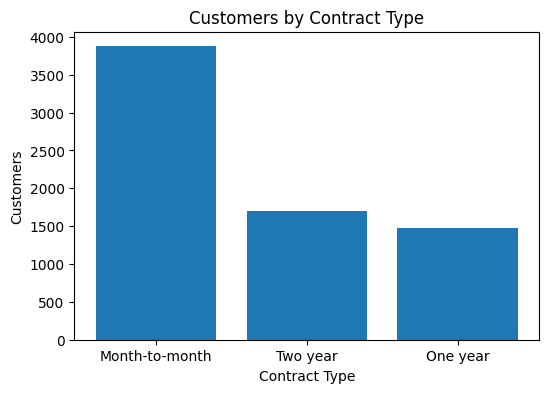

In [56]:
contract=df['Contract'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(contract.index,contract.values)
plt.title("Customers by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Customers")

plt.show()

### Internet Service Distribution

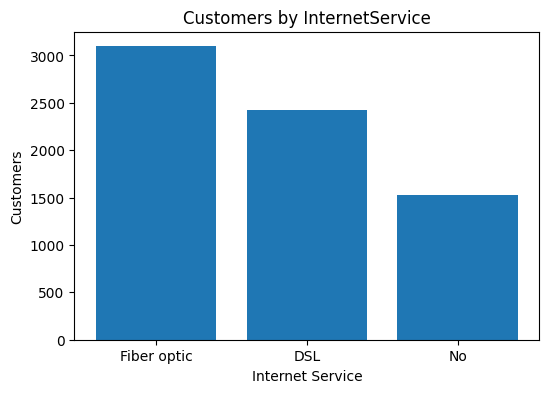

In [57]:
internet=df['InternetService'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(internet.index,internet.values)
plt.title("Customers by InternetService")
plt.xlabel("Internet Service")
plt.ylabel("Customers")

plt.show()

### Monthly Charges Distribution

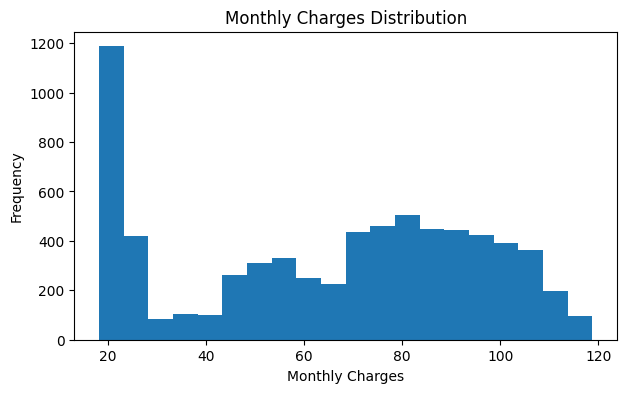

In [58]:
plt.figure(figsize=(7,4))
plt.hist(df['MonthlyCharges'], bins=20)
plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")
plt.show()

### Tenure Distribution

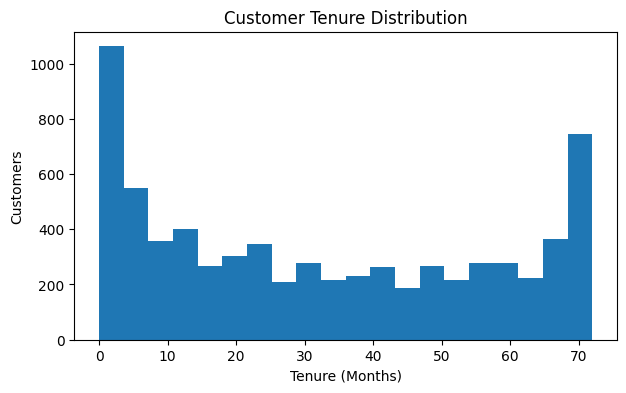

In [59]:
plt.figure(figsize=(7,4))
plt.hist(df['tenure'], bins=20)
plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Customers")
plt.show()

# DATA PREPROCESSING

### Removing the customer_id,because it does not help predict churn

In [60]:
df=df.drop('customerID',axis=1)

In [61]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,18.80,18.80,No
1,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Electronic check,18.85,18.85,No
2,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,18.85,18.85,Yes
3,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,18.90,18.90,No
4,Female,0,Yes,Yes,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,19.00,19.00,No


### Encoding the target variable

In [62]:
df['Churn']=df['Churn'].map({'No':0,'Yes':1})

In [63]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

#Encoding remaining categorical columns

In [64]:
df=pd.get_dummies(df,drop_first=True)

In [65]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,18.80,18.80,0,True,True,True,True,False,...,True,False,True,False,True,False,False,False,False,True
1,0,1,18.85,18.85,0,False,False,False,True,False,...,True,False,True,False,False,False,False,False,True,False
2,0,1,18.85,18.85,1,True,False,False,True,False,...,True,False,True,False,False,False,True,False,False,True
3,0,1,18.90,18.90,0,True,False,False,True,False,...,True,False,True,False,False,False,False,False,False,True
4,0,1,19.00,19.00,0,False,True,True,True,False,...,True,False,True,False,False,False,True,False,False,True


### Split features and target

In [66]:
X=df.drop("Churn",axis=1)
y=df["Churn"]

In [67]:
print(X.shape)
print(y.shape)

(7043, 30)
(7043,)


### Train Test Split

In [68]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [69]:
print(X_train.shape)
print(X_test.shape)

(5634, 30)
(1409, 30)


### Feature scaling

In [74]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)


### Training first model (Logistic Regression)


In [75]:
lr=LogisticRegression (random_state=42)
lr.fit(X_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### Make Predictions

In [77]:
y_pred_lr=lr.predict(X_test_scaled)

## Evaluating the model

### Accuracy

In [80]:
from sklearn.metrics import accuracy_score

accuracy=accuracy_score(y_test,y_pred_lr)
print(f"Accuracy:{accuracy:.4f}")

Accuracy:0.8055


### Confusion Matrix

In [83]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test,y_pred_lr)
print(cm)

[[935 100]
 [174 200]]


### Classification Report

In [84]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred_lr))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.67      0.53      0.59       374

    accuracy                           0.81      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



# Decision Tree Classifier

In [86]:
dt=DecisionTreeClassifier(random_state=42)

dt.fit(X_train,y_train)
y_pred_dt=dt.predict(X_test)

In [87]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.7182398864442867
[[824 211]
 [186 188]]
              precision    recall  f1-score   support

           0       0.82      0.80      0.81      1035
           1       0.47      0.50      0.49       374

    accuracy                           0.72      1409
   macro avg       0.64      0.65      0.65      1409
weighted avg       0.72      0.72      0.72      1409



# Random Forest

In [88]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)
y_pred_rf=rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7927608232789212
[[931 104]
 [188 186]]
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



# Comparison table

In [89]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [0.8055, 0.7182, 0.7928],
    "Precision": [0.67, 0.47, 0.64],
    "Recall": [0.53, 0.50, 0.50],
    "F1-Score": [0.59, 0.49, 0.56]
})

results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.8055,0.67,0.53,0.59
2,Random Forest,0.7928,0.64,0.50,0.56
1,Decision Tree,0.7182,0.47,0.50,0.49


# Feature Importance

In [92]:
feature_importance=pd.DataFrame({"Feature":X.columns,"Importance":rf.feature_importances_})

feature_importance=feature_importance.sort_values(by="Importance",ascending=False)
feature_importance.head(10)

,Feature,Importance
3,TotalCharges,0.191886
2,MonthlyCharges,0.172051
1,tenure,0.166831
10,InternetService_Fiber optic,0.040677
28,PaymentMethod_Electronic check,0.036786
25,Contract_Two year,0.033818
4,gender_Male,0.029125
13,OnlineSecurity_Yes,0.027744
26,PaperlessBilling_Yes,0.024838
5,Partner_Yes,0.023662


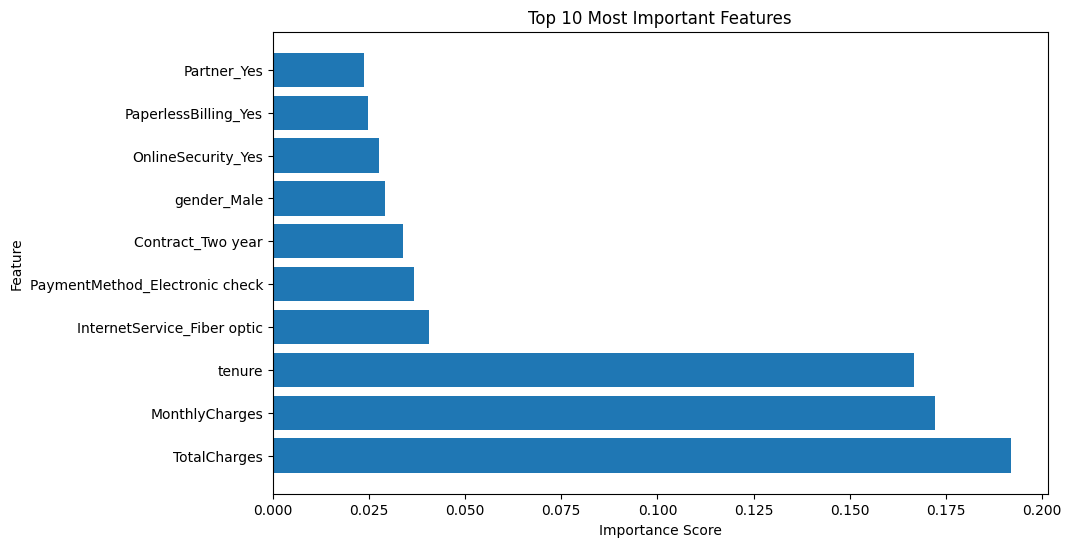

In [94]:
plt.figure(figsize=(10,6))

top10 = feature_importance.head(10)

plt.barh(top10["Feature"], top10["Importance"])

plt.title("Top 10 Most Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.show()

# Business Recommendations

Based on the SQL analysis, Power BI dashboard, and machine learning model, the following recommendations are proposed:

1. Focus retention campaigns on customers with Month-to-Month contracts.
2. Improve onboarding and engagement for new customers during their first year.
3. Review pricing and service quality for Fiber Optic customers.
4. Encourage customers to switch from Electronic Check to automatic payment methods.
5. Offer loyalty rewards and contract renewal incentives to reduce churn.
6. Use the trained machine learning model to identify high-risk customers and proactively target them with retention offers.

# Conclusion

This project combined SQL, Power BI, and Machine Learning to analyze and predict customer churn.

- SQL was used for data cleaning, exploration, and business analysis.
- Power BI was used to build an interactive dashboard for business stakeholders.
- Machine Learning models were developed to predict customer churn.

Among the evaluated models, Logistic Regression achieved the best overall performance with an accuracy of approximately 80.55%, making it the recommended baseline model for churn prediction in this dataset.

The insights generated from this project can help businesses identify high-risk customers early and implement targeted retention strategies.